## Practical 2: Dimensionality Reduction

### Preliminaries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import load_digits

### Data

In [3]:
digits = load_digits()
type(digits)


sklearn.utils._bunch.Bunch

In [4]:
X = digits.data

### 1. Exploratory data analysis

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

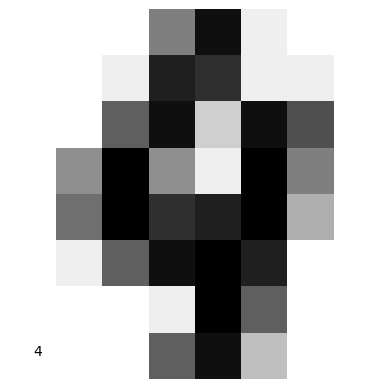

In [18]:
# Plot example
plt.imshow(X[14, :].reshape(8, 8), cmap=plt.cm.binary)
plt.text(0, 7, str(digits.target[14]))
plt.axis("off")

### 2. Dimensionality reduction using PCA

The goal in this section is to reduce each  8×8=64  dimensional image vectors to a vector of  𝑀  dimensions, where  𝑀<64 .

Question: 
- Is neccesary to normalize these data?
- Complete the code to perform PCA

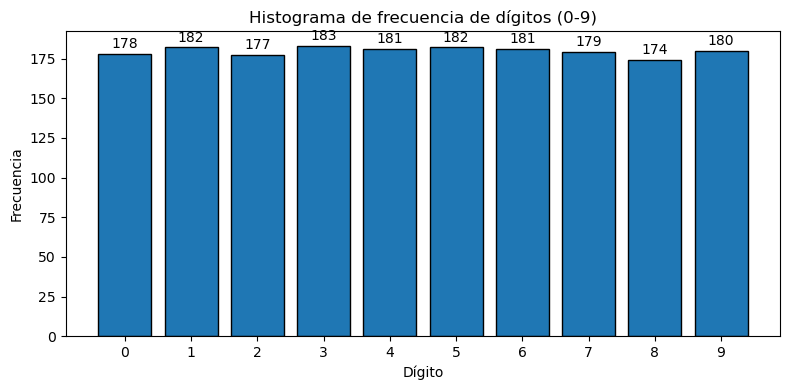

In [ ]:
# Answer: Complete the code
M = 2     # uncomment and set M to desired value
# Normalise the data to be zero-mean
# Answer: Add your own code here
X.max(axis=0) - X.min(axis=0)
# Centrar los datos para que la media sea cero
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# Ajustar PCA
pca = PCA(n_components=M)
pca.fit(X_centered)

# Primeras M direcciones (vectores propios / componentes principales)
W = pca.components_

# Proyectar los datos al espacio de menor dimensión
X_projected = pca.transform(X_centered)

# Reconstrucción en el espacio original (útil para visualizar)
X_reconstructed = pca.inverse_transform(X_projected)
 

# Fit the principal components analysis model
# Answer: Add your own code here
# Histograma de la frecuencia de cada dígito (0-9)
counts = np.bincount(digits.target, minlength=10)
plt.figure(figsize=(8,4))
plt.bar(np.arange(10), counts, color='C0', edgecolor='k')
plt.xlabel('Dígito')
plt.ylabel('Frecuencia')
plt.title('Histograma de frecuencia de dígitos (0-9)')
plt.xticks(np.arange(10))
for i, c in enumerate(counts):
    plt.text(i, c + max(counts)*0.01, str(c), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Fit a PCA with more components (useful to inspect the eigenvalue spectrum)
M_full = 64
pca_full = PCA(n_components=M_full)
pca_full.fit(X_centered)

# Save eigenvalues / explained variance for plotting / selection of M
eigenvalues = pca_full.explained_variance_
explained_variance_ratio = pca_full.explained_variance_ratio_



# Show the first two eigen vectors corresponding to the largest eigen values
# Answer: Add your own code here




# Project the data to the lower-dimensional space
# Answer: Add your own code here
# Project centered data onto the first M principal components (using W)
#X_lowdim = X_centered @ W.T
# keep the expected name for downstream cells
#X_projected = X_lowdim

To visualise the effect of the dimensionality reduction, we can project the reduced data back to the original feature space, and then plot the image. You can do this by (un)commenting the appropriate lines below.

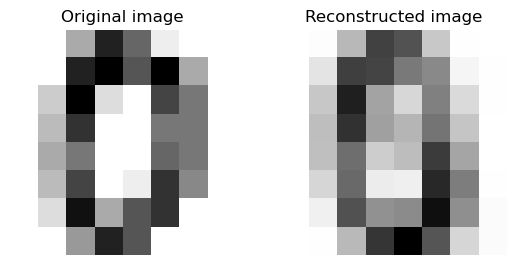

In [33]:
# Reconstruction
# X= original data 
# W:  projection vectors
# X_projected: projected data  (scores)
X_projected = pca.fit_transform(X)


#X_reconstructed = np.dot(X_projected, W.T)   
X_reconstructed = pca.inverse_transform(X_projected) # uncomment

# Plot the original and the reconstructed image
i_data = 0
plt.subplot(1, 2, 1)
plt.imshow(X[i_data, :].reshape(8, 8), cmap=plt.cm.binary) # uncomment
plt.title("Original image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Reconstructed image")
plt.imshow(X_reconstructed[i_data, :].reshape(8, 8), cmap=plt.cm.binary) # uncomment
plt.axis("off")
plt.show()

Question:

Repeat the above with different values of  𝑀  apart from  𝑀=2 . What is the effect on the reconstructions?

In [29]:
# Answer: Complete the code


Question: 

Plot all the eigenvalues, calculated for the larger 𝑀 the first part of Section 2, from large to small. What does this plot tell you? Can it help you pick an appropriate 𝑀 ?

In [9]:
# Answer: Complete the code

### 3. Visualising data with PCA 

Question: 

Use PCA to visualise all the digit images in 2-dimensions. 
Create a 2-dimensional scatter plot where each item is coloured according to its class.

In [10]:
# Answer: Complete the code

Question: Visualise the first two PCA projection vectors (principal directions)

PCA produces new orthogonal directions in the 64-dimensional image space.
These directions (PC1, PC2, …) can be interpreted as “spatial patterns” that explain most of the variability in the dataset.

In [11]:
# Answer: Complete the code